# Hyperparameter Tuning untuk Analisis Sentimen Berbasis Data Teks
### Pemodelan RNN, LSTM, dan GRU dengan TensorFlow/Keras

| Informasi | Detail |
|:----------|:-------|
| **Mata Kuliah** | Deep Learning |
| **Dosen Pengampu** | Ahmad Fathan Hidayatullah, Ph.D. |
| **Nama** | Muhammad Dhiauddin |
| **NIM** | 25917024 |
| **Konsentrasi** | Sains Data - Profesional |
| **Github** | [Mudhya19/Sentiment-Analysis-Hyperparameter-Tuning](https://github.com/Mudhya19/Sentiment-Analysis-Hyperparameter-Tuning) |
| **Kaggle** | [Indonesian Mobile Banking App Reviews Dataset](https://www.kaggle.com/datasets/reginakirana/indonesian-mobile-banking-app-reviews-dataset) |

---
> **Perhatian:** Letakkan `dataset_perbankan.csv` di `../data/raw/` sebelum menjalankan notebook ini dari folder `notebooks/`.

---
# Bab 1: Pendahuluan & Import Library

Bab ini menyiapkan seluruh pustaka yang dibutuhkan dan menetapkan **random seed global (SEED = 42)** pada Numpy, Python `random`, dan TensorFlow agar setiap eksekusi ulang menghasilkan output yang identik (*reproducibility*).

In [1]:
# Instalasi pustaka (jalankan sekali, lalu restart kernel jika diperlukan)
# !pip install tensorflow optuna scikit-learn pandas numpy matplotlib seaborn tqdm


In [2]:
# ════════════════════════════════════════════════════════════
#  IMPORT LIBRARY & KONFIGURASI GLOBAL
# ════════════════════════════════════════════════════════════
import os
import re
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:.4f}'.format

# ── RANDOM SEED GLOBAL ───────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import logging
os.makedirs('../logs', exist_ok=True)
log_format = '%(asctime)s - %(name)s - %(levelname)s - %(message)s'
# Setup logging ke file
logging.basicConfig(filename='../logs/experiment.log', level=logging.INFO, 
                    format=log_format, filemode='w')
logger = logging.getLogger('sentiment_experiment')
logger.info('=== EKSPERIMEN DIMULAI ===')

import optuna
# Arahkan log optuna ke file agar console jupyter tetap rapi
optuna.logging.disable_default_handler()  # Matikan print ke console notebook
optuna_logger = logging.getLogger('optuna')
optuna_logger.setLevel(logging.INFO)
fh = logging.FileHandler('../logs/optuna_study.log', mode='w')
fh.setFormatter(logging.Formatter(log_format))
optuna_logger.addHandler(fh)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# ── KONSTANTA EKSPERIMEN ─────────────────────────────────
VOCAB_SIZE    = 10_000  # Ukuran kosakata maksimum
MAX_LEN       = 100     # Panjang sekuens setelah padding
EMBEDDING_DIM = 64      # Dimensi embedding (statis)
MAX_EPOCHS    = 20      # Epoch maksimum per trial
PATIENCE      = 3       # EarlyStopping patience
N_TRIALS      = 30      # Trial Optuna per arsitektur (kurangi jika CPU terbatas)
TEST_SIZE     = 0.15    # Proporsi data uji
VAL_SIZE      = 0.15    # Proporsi data validasi
ARCH_LIST     = ['RNN', 'LSTM', 'GRU']
PALETTE       = ['#BBDEFB', '#42A5F5', '#0D47A1']

print('Semua library berhasil diimport!')
print(f'  TensorFlow : {tf.__version__}')
print(f'  Optuna     : {optuna.__version__}')
print(f'  SEED       : {SEED}')
print(f'  N_TRIALS   : {N_TRIALS} per arsitektur ({N_TRIALS * 3} total)')


Semua library berhasil diimport!
  TensorFlow : 2.21.0
  Optuna     : 4.9.0
  SEED       : 42
  N_TRIALS   : 30 per arsitektur (90 total)


---
# Bab 2: Deskripsi Dataset

## 2.1 Informasi Dataset

| Atribut | Keterangan |
|:--------|:-----------|
| **Nama** | Indonesian Mobile Banking App Reviews Dataset |
| **Sumber** | [Kaggle – reginakirana](https://www.kaggle.com/datasets/reginakirana/indonesian-mobile-banking-app-reviews-dataset) |
| **Jumlah Data** | ± 12.000 ulasan |
| **Kelas Sentimen** | 3 kelas: Positif, Negatif, Netral |
| **Bahasa** | Indonesia |
| **Deskripsi** | Dataset berisi ulasan pengguna aplikasi *mobile banking* berbahasa Indonesia dari Google Play Store yang telah dilabeli sentimen positif, negatif, dan netral. Relevan untuk menguji model NLP berbasis RNN dalam memahami konteks bahasa informal Indonesia. |

## 2.2 Memuat & Mengeksplorasi Dataset


In [3]:
# ════════════════════════════════════════════════════════════
#  2.2 MUAT DATASET
# ════════════════════════════════════════════════════════════

POSSIBLE_PATHS = [
    '../data/raw/dataset_perbankan.csv',
    'data/raw/dataset_perbankan.csv',
    'dataset_perbankan.csv',
    '../dataset_perbankan.csv',
]

df_raw = None
for _path in POSSIBLE_PATHS:
    if os.path.exists(_path):
        try:
            df_raw = pd.read_csv(_path, encoding='utf-8')
        except UnicodeDecodeError:
            df_raw = pd.read_csv(_path, encoding='latin-1')
        print(f'Dataset dimuat dari : {_path}')
        break

if df_raw is None:
    raise FileNotFoundError(
        "File 'dataset_perbankan.csv' tidak ditemukan!\n"
        "Letakkan file di salah satu path berikut:\n"
        + "\n".join(f"  - {p}" for p in POSSIBLE_PATHS)
    )

print(f'Shape dataset : {df_raw.shape}  '
      f'({df_raw.shape[0]:,} baris x {df_raw.shape[1]} kolom)')
print(f'Kolom         : {df_raw.columns.tolist()}')


Dataset dimuat dari : ../data/raw/dataset_perbankan.csv
Shape dataset : (12000, 10)  (12,000 baris x 10 kolom)
Kolom         : ['reviewId', 'userName', 'score', 'content', 'thumbsUpCount', 'at', 'replyContent', 'repliedAt', 'label', 'app_name']


In [4]:
# ── Deteksi Kolom Teks & Label Otomatis ─────────────────────
_TEXT_CANDS  = ['review','text','content','ulasan','komentar',
                'Review','Text','Content','Ulasan','comment']
_LABEL_CANDS = ['sentiment','label','sentimen','Sentiment',
                'Label','class','Class','score','kategori']

TEXT_COL  = next((c for c in _TEXT_CANDS  if c in df_raw.columns), None)
LABEL_COL = next((c for c in _LABEL_CANDS if c in df_raw.columns), None)

if TEXT_COL is None:
    TEXT_COL = df_raw.columns[0]
    print(f'Kolom teks tidak terdeteksi, pakai kolom pertama: {TEXT_COL}')
if LABEL_COL is None:
    LABEL_COL = df_raw.columns[-1]
    print(f'Kolom label tidak terdeteksi, pakai kolom terakhir: {LABEL_COL}')

print(f'Kolom Teks  : "{TEXT_COL}"')
print(f'Kolom Label : "{LABEL_COL}"')

df = df_raw[[TEXT_COL, LABEL_COL]].copy()
df.columns = ['text', 'label']
df['label'] = df['label'].astype(str).str.strip()

# Drop baris dengan nilai null
df.dropna(subset=['text', 'label'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'\nJumlah data valid : {len(df):,}')
print('\n5 Contoh Data:')
display(df.head())


Kolom Teks  : "content"
Kolom Label : "label"

Jumlah data valid : 12,000

5 Contoh Data:


,text,label
0,puas banget dengan layanan aplikasi mybca mobi...,negatif
1,transfer ke bank lain di mutasi ada tp tidak m...,negatif
2,"Tolong dijawab, Kenapa ada BCA MOBILE dan myBC...",positif
3,kenapa lampu indikatornya merah trs saat ingin...,negatif
4,TOLONG DONK BCA KENAPA LAMPU INDIKATOR MERAH T...,negatif


In [5]:
# ── Info & Missing Values ────────────────────────────────────
print('=== INFO DATASET ===')
df.info()
print('\n=== MISSING VALUES ===')
print(df.isnull().sum())


=== INFO DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    12000 non-null  str  
 1   label   12000 non-null  str  
dtypes: str(2)
memory usage: 187.6 KB

=== MISSING VALUES ===
text     0
label    0
dtype: int64


=== DISTRIBUSI LABEL SENTIMEN ===


,Kelas,Jumlah,Persentase (%)
1,positif,7004,58.3700
2,negatif,4254,35.4500
3,netral,742,6.1800


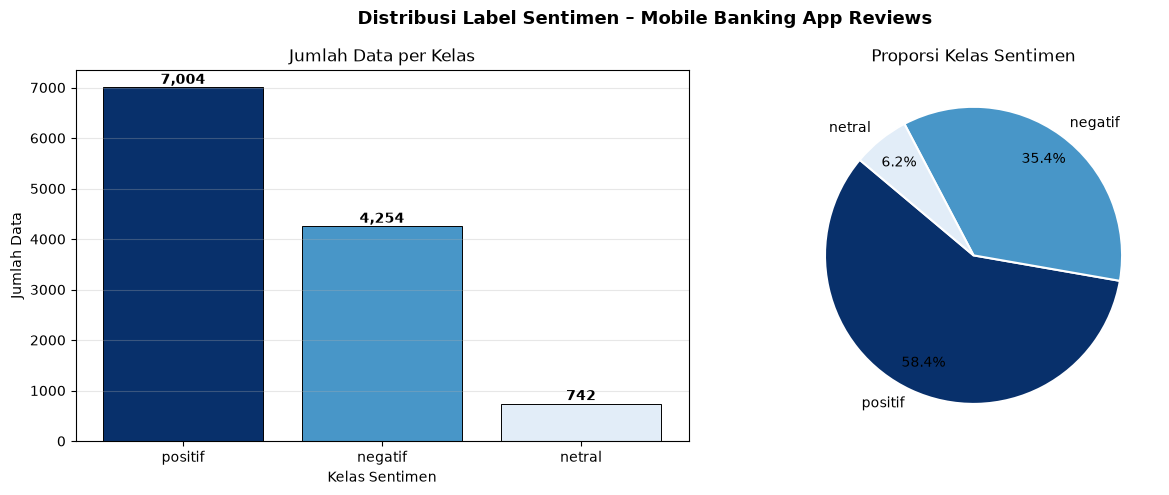

Gambar disimpan -> '../images/output/distribusi_label.png'


In [6]:
# ════════════════════════════════════════════════════════════
#  2.3 DISTRIBUSI LABEL SENTIMEN
# ════════════════════════════════════════════════════════════

label_counts = df['label'].value_counts()
label_pct    = df['label'].value_counts(normalize=True) * 100

dist_df = pd.DataFrame({
    'Kelas'           : label_counts.index,
    'Jumlah'          : label_counts.values,
    'Persentase (%)' : label_pct.values.round(2)
}).reset_index(drop=True)
dist_df.index += 1
print('=== DISTRIBUSI LABEL SENTIMEN ===')
display(dist_df)

# ── Visualisasi Bar + Pie ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribusi Label Sentimen – Mobile Banking App Reviews',
             fontsize=13, fontweight='bold')

_colors = ['#4CAF50', '#F44336', '#2196F3', '#FF9800', '#9C27B0']
import matplotlib.cm as cm
import matplotlib.colors as mcolors

norm_c = mcolors.Normalize(vmin=0, vmax=max(label_counts.values))
color_map = {lbl: cm.Blues(norm_c(val)) for lbl, val in zip(label_counts.index, label_counts.values)}
_colors = [color_map[lbl] for lbl in label_counts.index]

axes[0].bar(label_counts.index, label_counts.values,
            color=_colors,
            edgecolor='black', linewidth=0.7)
axes[0].set_title('Jumlah Data per Kelas')
axes[0].set_xlabel('Kelas Sentimen')
axes[0].set_ylabel('Jumlah Data')
axes[0].grid(axis='y', alpha=0.3)
for i, (_, val) in enumerate(zip(label_counts.index, label_counts.values)):
    axes[0].text(i, val + max(label_counts) * 0.01,
                 f'{val:,}', ha='center', fontweight='bold')

axes[1].pie(label_counts.values, labels=label_counts.index,
            colors=_colors[:len(label_counts)],
            autopct='%1.1f%%', startangle=140, pctdistance=0.8,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Proporsi Kelas Sentimen')

plt.tight_layout()
os.makedirs('../images/output', exist_ok=True)
plt.savefig('../images/output/distribusi_label.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gambar disimpan -> '../images/output/distribusi_label.png'")


## 2.4 Exploratory Data Analysis (EDA)

Analisis eksplorasi untuk memahami karakteristik data teks secara lebih mendalam sebelum masuk ke tahap preprocessing.


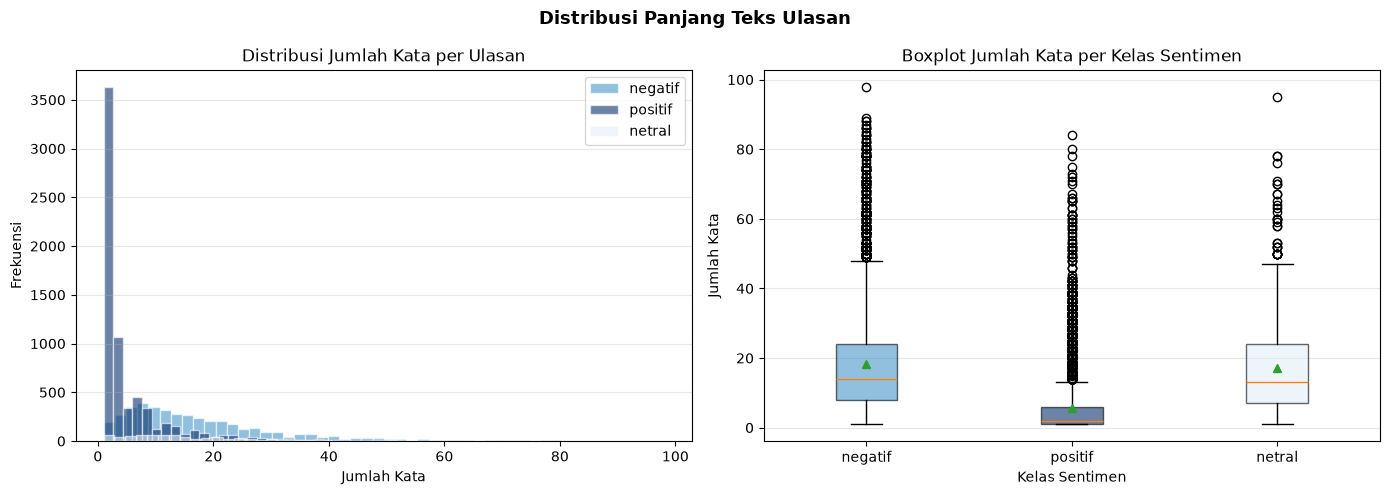

=== STATISTIK PANJANG TEKS (JUMLAH KATA) PER KELAS ===


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
negatif,4254.0000,18.2000,14.7700,1.0000,8.0000,14.0000,24.0000,98.0000
netral,742.0000,17.1700,14.0100,1.0000,7.0000,13.0000,24.0000,95.0000
positif,7004.0000,5.6800,8.2800,1.0000,1.0000,2.0000,6.0000,84.0000



Gambar disimpan -> '../images/output/eda_distribusi_panjang_teks.png'


In [7]:
# ════════════════════════════════════════════════════════════
#  2.4a DISTRIBUSI PANJANG TEKS (JUMLAH KATA)
# ════════════════════════════════════════════════════════════

df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['text'].apply(lambda x: len(str(x)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Panjang Teks Ulasan', fontsize=13, fontweight='bold')

# Histogram jumlah kata
for lbl in (CLASS_NAMES if 'CLASS_NAMES' in dir() else df['label'].unique()):
    subset = df[df['label'] == lbl]['word_count']
    axes[0].hist(subset, bins=50, alpha=0.6, label=lbl, color=color_map.get(lbl, 'blue'), edgecolor='white')
axes[0].set_title('Distribusi Jumlah Kata per Ulasan')
axes[0].set_xlabel('Jumlah Kata')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Boxplot jumlah kata per label
labels_unique = df['label'].unique().tolist()
box_data = [df[df['label'] == lbl]['word_count'].values for lbl in labels_unique]
bp = axes[1].boxplot(box_data, patch_artist=True,
                     showmeans=True, showfliers=True)
axes[1].set_xticks(range(1, len(labels_unique) + 1))
axes[1].set_xticklabels(labels_unique)
for patch, lbl in zip(bp['boxes'], labels_unique):
    patch.set_facecolor(color_map.get(lbl, 'blue'))
    patch.set_alpha(0.6)
axes[1].set_title('Boxplot Jumlah Kata per Kelas Sentimen')
axes[1].set_xlabel('Kelas Sentimen')
axes[1].set_ylabel('Jumlah Kata')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/output/eda_distribusi_panjang_teks.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Statistik deskriptif panjang teks
print('=== STATISTIK PANJANG TEKS (JUMLAH KATA) PER KELAS ===')
display(df.groupby('label')['word_count'].describe().round(2))
print(f"\nGambar disimpan -> '../images/output/eda_distribusi_panjang_teks.png'")


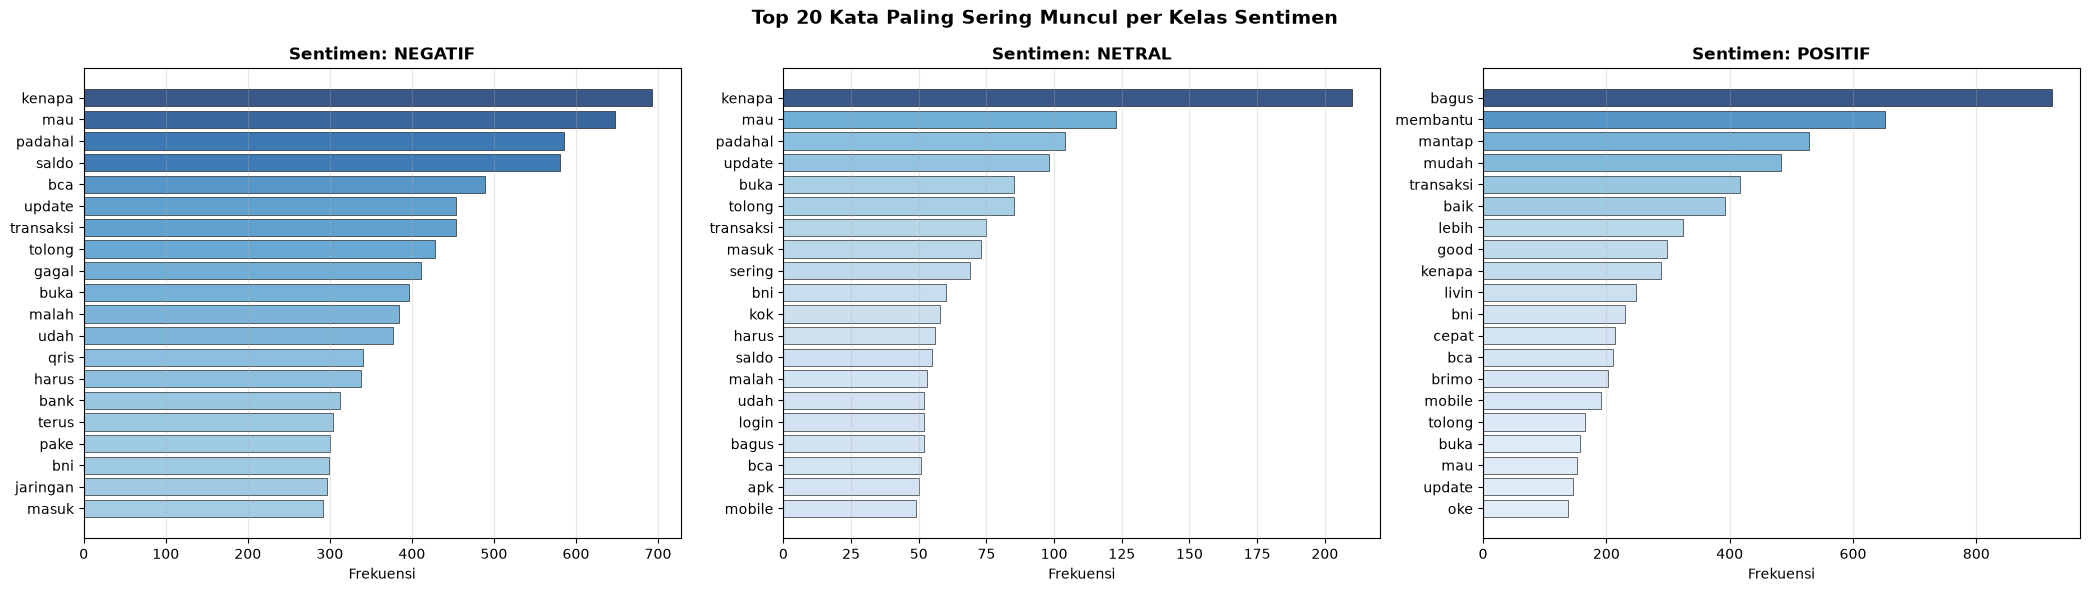

Gambar disimpan -> '../images/output/eda_top_words_per_kelas.png'


In [8]:
# ════════════════════════════════════════════════════════════
#  2.4b TOP 20 KATA PALING SERING MUNCUL PER KELAS
# ════════════════════════════════════════════════════════════

from collections import Counter

fig, axes = plt.subplots(1, len(df['label'].unique()),
                         figsize=(7 * len(df['label'].unique()), 6))
if len(df['label'].unique()) == 1:
    axes = [axes]

fig.suptitle('Top 20 Kata Paling Sering Muncul per Kelas Sentimen',
             fontsize=14, fontweight='bold')

for ax, lbl in zip(axes, sorted(df['label'].unique())):
    all_words = ' '.join(df[df['label'] == lbl]['text'].astype(str).str.lower()).split()
    # Filter stopwords sederhana bahasa Indonesia
    stop_id = {'yang','dan','di','ini','itu','dengan','untuk','tidak','dari',
              'ke','ada','pada','juga','sudah','saya','bisa','atau','akan',
              'ya','lagi','sangat','sekali','tapi','karena','kalau','aja',
              'nya','yg','gak','ga','nih','dong','deh','sih','the','is','a',
              'to','and','of','in','for','it','this','was','my','app','aplikasi'}
    filtered = [w for w in all_words if w not in stop_id and len(w) > 2]
    top20 = Counter(filtered).most_common(20)
    words, counts = zip(*top20) if top20 else ([], [])
    norm_w = mcolors.Normalize(vmin=0, vmax=max(counts))
    bar_colors = [cm.Blues(norm_w(c)) for c in list(reversed(counts))]
    ax.barh(list(reversed(words)), list(reversed(counts)),
            color=bar_colors, edgecolor='black', linewidth=0.5, alpha=0.8)
    ax.set_title(f'Sentimen: {lbl.upper()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Frekuensi')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/output/eda_top_words_per_kelas.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Gambar disimpan -> '../images/output/eda_top_words_per_kelas.png'")


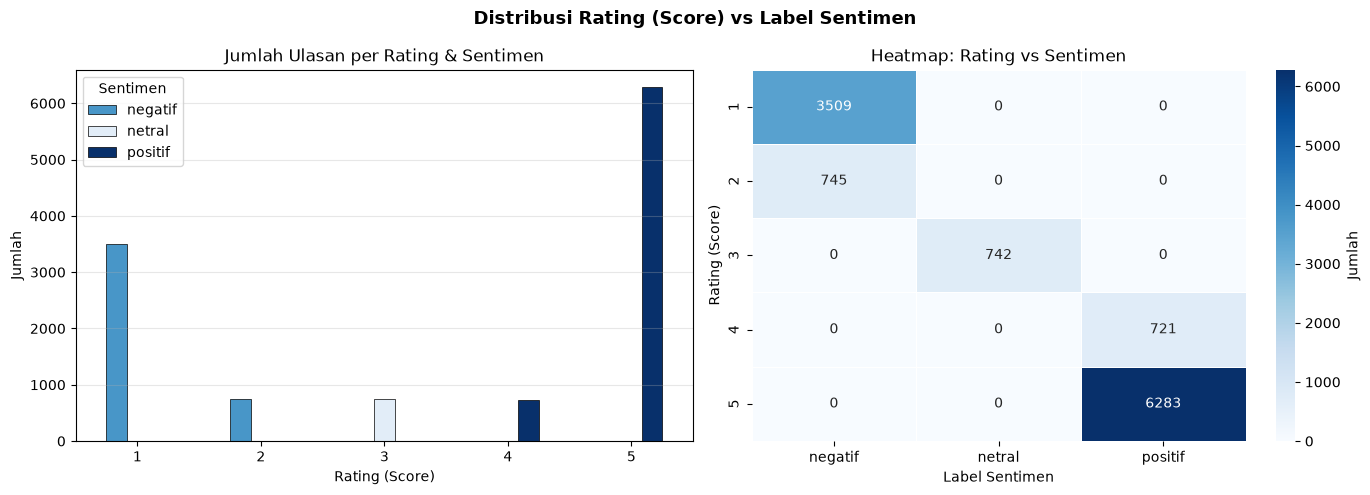

Gambar disimpan -> '../images/output/eda_rating_vs_sentimen.png'


In [9]:
# ════════════════════════════════════════════════════════════
#  2.4c DISTRIBUSI RATING (SCORE) PER KELAS SENTIMEN
# ════════════════════════════════════════════════════════════

if 'score' in df_raw.columns:
    _score_col = 'score'
elif 'Score' in df_raw.columns:
    _score_col = 'Score'
elif 'rating' in df_raw.columns:
    _score_col = 'rating'
else:
    _score_col = None

if _score_col is not None:
    df['score'] = df_raw.loc[df.index, _score_col].values
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Distribusi Rating (Score) vs Label Sentimen',
                 fontsize=13, fontweight='bold')

    # Countplot rating per sentimen
    score_label_ct = df.groupby(['score', 'label']).size().unstack(fill_value=0)
    score_label_ct.plot(kind='bar', ax=axes[0],
                       color=[color_map.get(c, 'blue') for c in score_label_ct.columns],
                       edgecolor='black', linewidth=0.5)
    axes[0].set_title('Jumlah Ulasan per Rating & Sentimen')
    axes[0].set_xlabel('Rating (Score)')
    axes[0].set_ylabel('Jumlah')
    axes[0].legend(title='Sentimen')
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].tick_params(axis='x', rotation=0)

    # Heatmap rating vs sentimen
    ct_matrix = pd.crosstab(df['score'], df['label'])
    sns.heatmap(ct_matrix, annot=True, fmt='d', cmap='Blues',
                ax=axes[1], linewidths=0.5, cbar_kws={'label': 'Jumlah'})
    axes[1].set_title('Heatmap: Rating vs Sentimen')
    axes[1].set_xlabel('Label Sentimen')
    axes[1].set_ylabel('Rating (Score)')

    plt.tight_layout()
    plt.savefig('../images/output/eda_rating_vs_sentimen.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("Gambar disimpan -> '../images/output/eda_rating_vs_sentimen.png'")
else:
    print('Kolom score/rating tidak ditemukan di dataset, skip visualisasi ini.')


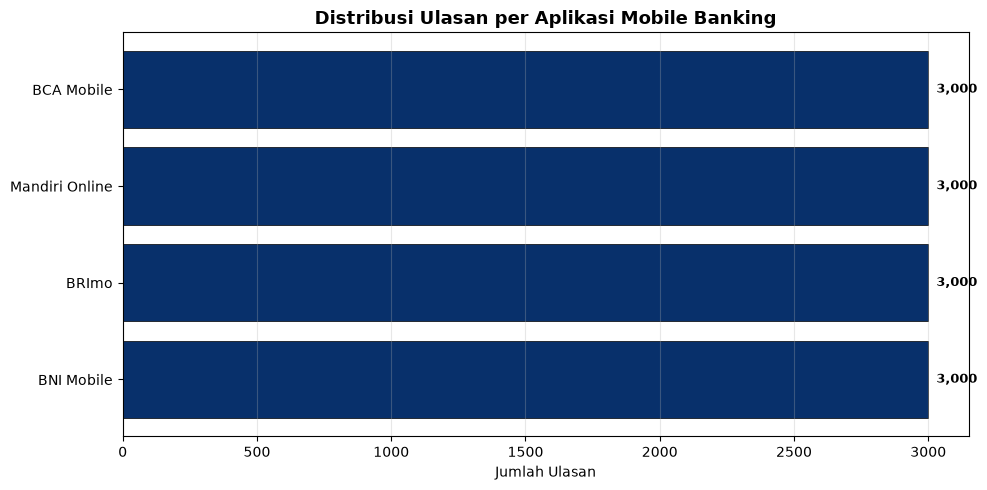

Jumlah aplikasi unik: 4


,Jumlah Ulasan,count
0,BCA Mobile,3000
1,Mandiri Online,3000
2,BRImo,3000
3,BNI Mobile,3000


Gambar disimpan -> '../images/output/eda_distribusi_app.png'


In [10]:
# ════════════════════════════════════════════════════════════
#  2.4d DISTRIBUSI APLIKASI MOBILE BANKING
# ════════════════════════════════════════════════════════════

if 'app_name' in df_raw.columns:
    app_counts = df_raw['app_name'].value_counts()
    fig, ax = plt.subplots(figsize=(10, 5))
    norm_a = mcolors.Normalize(vmin=0, vmax=max(app_counts.values))
    bar_colors = [cm.Blues(norm_a(c)) for c in app_counts.values[::-1]]
    ax.barh(app_counts.index[::-1], app_counts.values[::-1],
            color=bar_colors,
            edgecolor='black', linewidth=0.5)
    for i, (name, val) in enumerate(zip(app_counts.index[::-1],
                                         app_counts.values[::-1])):
        ax.text(val + max(app_counts) * 0.01, i,
                f'{val:,}', va='center', fontweight='bold', fontsize=9)
    ax.set_title('Distribusi Ulasan per Aplikasi Mobile Banking',
                fontsize=13, fontweight='bold')
    ax.set_xlabel('Jumlah Ulasan')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('../images/output/eda_distribusi_app.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Jumlah aplikasi unik: {len(app_counts)}')
    display(app_counts.reset_index().rename(
        columns={'index': 'Aplikasi', 'app_name': 'Jumlah Ulasan'}))
    print("Gambar disimpan -> '../images/output/eda_distribusi_app.png'")
else:
    print('Kolom app_name tidak ditemukan di dataset, skip visualisasi ini.')


---
# Bab 3: Preprocessing Data

| Langkah | Teknik | Keterangan |
|:--------|:-------|:-----------|
| **3.1 Text Cleansing** | Regex | Lowercase · hapus URL · karakter non-alfabet · normalisasi spasi |
| **3.2 Label Encoding** | `LabelEncoder` | String label → Integer (0, 1, 2) |
| **3.3 Tokenisasi** | `Keras Tokenizer` | Fit **hanya** pada data latih (mencegah *data leakage*) |
| **3.4 Padding** | `pad_sequences` | Seragamkan panjang → `MAX_LEN=100` |
| **3.5 Split** | `train_test_split` stratified | 70% Train · 15% Val · 15% Test |


In [11]:
# ════════════════════════════════════════════════════════════
#  3.1 TEXT CLEANSING
# ════════════════════════════════════════════════════════════

def clean_text(text: str) -> str:
    """Membersihkan teks ulasan bahasa Indonesia untuk NLP."""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # hapus URL
    text = re.sub(r'@\w+|#\w+', '', text)                 # hapus mention/hashtag
    text = re.sub(r'[^a-z\s]', ' ', text)                  # hanya huruf & spasi
    text = re.sub(r'\s+', ' ', text).strip()               # hapus spasi berlebih
    return text

df['text_clean'] = df['text'].apply(clean_text)

n_before = len(df)
df = df[df['text_clean'].str.len() > 2].reset_index(drop=True)
n_after  = len(df)

print(f'Text cleansing selesai.')
print(f'  Sebelum : {n_before:,} baris')
print(f'  Sesudah : {n_after:,} baris  ({n_before - n_after} baris dihapus)')
print('\n3 Contoh Sebelum & Sesudah Cleansing:')
for idx in df.sample(3, random_state=SEED).index:
    print(f'\n  [SEBELUM] {df.at[idx, "text"][:120]}')
    print(f'  [SESUDAH] {df.at[idx, "text_clean"][:120]}')


Text cleansing selesai.
  Sebelum : 12,000 baris
  Sesudah : 11,536 baris  (464 baris dihapus)

3 Contoh Sebelum & Sesudah Cleansing:

  [SEBELUM] Good app.
  [SESUDAH] good app

  [SEBELUM] baik dan bagus
  [SESUDAH] baik dan bagus

  [SEBELUM] gagal verif wajah 6x, sangat disayangkan
  [SESUDAH] gagal verif wajah x sangat disayangkan


In [12]:
# ════════════════════════════════════════════════════════════
#  3.2 LABEL ENCODING
# ════════════════════════════════════════════════════════════

le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])

NUM_CLASSES = len(le.classes_)
CLASS_NAMES = list(le.classes_)

print(f'Label encoding selesai.')
print(f'  Kelas asal   : {CLASS_NAMES}')
print(f'  Kode numerik : {list(range(NUM_CLASSES))}')
print(f'  Jumlah kelas : {NUM_CLASSES}')

display(pd.DataFrame({'Label Asli': CLASS_NAMES,
                      'Kode Numerik': list(range(NUM_CLASSES))}))


Label encoding selesai.
  Kelas asal   : ['negatif', 'netral', 'positif']
  Kode numerik : [0, 1, 2]
  Jumlah kelas : 3


,Label Asli,Kode Numerik
0,negatif,0
1,netral,1
2,positif,2


In [13]:
# ════════════════════════════════════════════════════════════
#  3.3-3.5 TOKENISASI, PADDING & SPLIT DATA
# ════════════════════════════════════════════════════════════

X = df['text_clean'].values
y = df['label_enc'].values

# Langkah 1: pisahkan Test (15%) dari sisa data
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)

# Langkah 2: dari sisa 85%, pisahkan Val agar total Val ~15%
_val_ratio = VAL_SIZE / (1.0 - TEST_SIZE)  # 0.15/0.85 ~= 0.1765
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=_val_ratio,
    random_state=SEED,
    stratify=y_temp
)

print('Pembagian data (Stratified Split):')
print(f'  Train : {len(X_train):>6,}  ({len(X_train)/len(X)*100:.1f}%)')
print(f'  Val   : {len(X_val):>6,}  ({len(X_val)/len(X)*100:.1f}%)')
print(f'  Test  : {len(X_test):>6,}  ({len(X_test)/len(X)*100:.1f}%)')
print(f'  Total : {len(X):>6,}')

# ── Tokenizer: fit HANYA pada data Train (cegah data leakage)
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

print(f'\nTokenizer selesai.')
print(f'  Kosakata unik ditemukan : {len(tokenizer.word_index):,}')
print(f'  Vocab yang digunakan    : {min(len(tokenizer.word_index)+1, VOCAB_SIZE+1):,}')

# ── Konversi teks -> sekuens integer -> padding ──────────────
def to_padded(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

X_train_seq = to_padded(X_train)
X_val_seq   = to_padded(X_val)
X_test_seq  = to_padded(X_test)

print(f'\nPadding selesai (MAX_LEN={MAX_LEN}):')
print(f'  X_train_seq : {X_train_seq.shape}')
print(f'  X_val_seq   : {X_val_seq.shape}')
print(f'  X_test_seq  : {X_test_seq.shape}')


Pembagian data (Stratified Split):
  Train :  8,074  (70.0%)
  Val   :  1,731  (15.0%)
  Test  :  1,731  (15.0%)
  Total : 11,536

Tokenizer selesai.
  Kosakata unik ditemukan : 6,510
  Vocab yang digunakan    : 6,511

Padding selesai (MAX_LEN=100):
  X_train_seq : (8074, 100)
  X_val_seq   : (1731, 100)
  X_test_seq  : (1731, 100)


---
# Bab 4: Arsitektur Model

## 4.1 Desain Arsitektur

Tiga arsitektur diuji dengan **struktur yang identik** agar perbandingan adil:

```
Input (sekuens integer, panjang MAX_LEN=100)
  └─ Embedding  [VOCAB_SIZE x EMBEDDING_DIM=64]  <- STATIS
      └─ RNN / LSTM / GRU  [units]              <- hyperparameter
          └─ Dropout  [rate]                    <- hyperparameter
              └─ Dense Softmax  [num_classes]
```

## 4.2 Parameter Statis vs Hyperparameter

| Jenis | Parameter | Nilai |
|:------|:----------|:------|
| **Statis** | Jumlah layer rekuren | 1 |
| **Statis** | Dimensi embedding | 64 |
| **Statis** | Optimizer | Adam |
| **Statis** | Loss | Sparse Categorical Crossentropy |
| **Statis** | Max epoch | 20 + EarlyStopping |
| **Hyperparameter** | Learning rate | [1e-4, 1e-2] log-uniform |
| **Hyperparameter** | Batch size | {16, 32, 64} |
| **Hyperparameter** | Hidden units | {32, 64, 128} |
| **Hyperparameter** | Dropout rate | [0.1, 0.5] uniform |


In [14]:
# ════════════════════════════════════════════════════════════
#  4.3 FUNGSI PEMBANGUN MODEL
# ════════════════════════════════════════════════════════════

ARCH_LAYER_MAP = {
    'RNN' : SimpleRNN,
    'LSTM': LSTM,
    'GRU' : GRU,
}

def build_model(model_type: str,
                units: int,
                dropout_rate: float,
                learning_rate: float) -> tf.keras.Model:
    """
    Membangun model Sequential dengan satu layer rekuren.

    Parameters
    ----------
    model_type    : 'RNN', 'LSTM', atau 'GRU'
    units         : Jumlah hidden units [hyperparameter]
    dropout_rate  : Tingkat dropout [hyperparameter]
    learning_rate : Learning rate Adam [hyperparameter]
    """
    if model_type not in ARCH_LAYER_MAP:
        raise ValueError(f'model_type harus salah satu dari '
                         f'{list(ARCH_LAYER_MAP.keys())}')
    RecLayer = ARCH_LAYER_MAP[model_type]

    model = Sequential([
        Embedding(input_dim=VOCAB_SIZE + 1,
                  output_dim=EMBEDDING_DIM,
                  input_length=MAX_LEN,
                  name='embedding'),
        RecLayer(units, name=f'{model_type.lower()}_layer'),
        Dropout(dropout_rate, name='dropout'),
        Dense(NUM_CLASSES, activation='softmax', name='output'),
    ], name=f'Model_{model_type}')

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ── Tampilkan ringkasan arsitektur ketiga model ─────────────
for _arch in ARCH_LIST:
    print(f'\n{"="*60}')
    print(f'  Arsitektur: {_arch} (units=64, dropout=0.3, lr=1e-3)')
    print(f'{"="*60}')
    _demo = build_model(_arch, 64, 0.3, 1e-3)
    _demo.summary()
    del _demo
tf.keras.backend.clear_session()



  Arsitektur: RNN (units=64, dropout=0.3, lr=1e-3)


Model: "Model_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_layer (SimpleRNN)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

Model: "Model_GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_layer (GRU)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

---
# Bab 5: Skenario Hyperparameter Tuning

## 5.1 Metode: Optuna dengan TPE

**Optuna** dengan algoritma **TPE (Tree-structured Parzen Estimator)** adalah metode Bayesian Optimization yang secara adaptif mengeksplorasi ruang pencarian berdasarkan hasil trial sebelumnya, jauh lebih efisien daripada Grid Search maupun Random Search.

## 5.2 Ruang Pencarian Hyperparameter

| # | Hyperparameter | Tipe | Rentang / Pilihan | Alasan |
|:-:|:--------------|:-----|:-----------------|:-------|
| 1 | **Learning Rate** | Log-uniform | [1e-4, 1e-2] | Skala log agar eksplorasi merata; rentang standar Adam untuk NLP |
| 2 | **Batch Size** | Kategoris | {16, 32, 64} | Batch kecil → gradien berisik (generalisasi baik); batch besar → training stabil |
| 3 | **Hidden Units** | Kategoris | {32, 64, 128} | Menguji kapasitas model dari sederhana hingga kompleks |
| 4 | **Dropout Rate** | Uniform | [0.1, 0.5] | Regularisasi standar NLP; mencegah overfitting |

## 5.3 Protokol Eksperimen

| Aspek | Konfigurasi |
|:------|:------------|
| **Data untuk evaluasi tuning** | `X_val` / `y_val` (data uji **tersembunyi**) |
| **Metrik optimasi** | Macro F1-Score (adil untuk kelas tidak seimbang) |
| **Trial budget** | 30 trial per arsitektur (90 total) |
| **Sampler** | `TPESampler(seed=42)` |
| **Early Stopping** | patience=3, monitor `val_loss` |
| **Reproduksibilitas** | SEED=42 + seed per trial |


In [15]:
# ════════════════════════════════════════════════════════════
#  5.4 FUNGSI OBJEKTIF OPTUNA
# ════════════════════════════════════════════════════════════

def make_objective(model_type: str):
    """
    Factory function: mengembalikan fungsi objektif Optuna
    untuk arsitektur model tertentu.

    Alur:
      trial saran HP -> bangun model -> latih pada Train
      -> prediksi pada Val -> kembalikan Macro F1 untuk dimaksimalkan
    """
    def objective(trial: optuna.Trial) -> float:
        tf.keras.backend.clear_session()
        tf.random.set_seed(SEED + trial.number)

        # ── Sarankan hyperparameter ──────────────────────
        lr           = trial.suggest_float(
            'learning_rate', 1e-4, 1e-2, log=True)
        batch_size   = trial.suggest_categorical(
            'batch_size', [16, 32, 64])
        units        = trial.suggest_categorical(
            'hidden_units', [32, 64, 128])
        dropout_rate = trial.suggest_float(
            'dropout_rate', 0.1, 0.5)

        # ── Bangun & latih model ─────────────────────────
        model = build_model(model_type, units, dropout_rate, lr)

        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=0
        )
        model.fit(
            X_train_seq, y_train,
            validation_data=(X_val_seq, y_val),
            epochs=MAX_EPOCHS,
            batch_size=batch_size,
            callbacks=[early_stop],
            verbose=0
        )

        # ── Evaluasi di data VALIDASI (bukan test!) ──────
        y_pred = np.argmax(
            model.predict(X_val_seq, verbose=0), axis=1)

        acc  = float(accuracy_score(y_val, y_pred))
        prec = float(precision_score(
            y_val, y_pred, average='macro', zero_division=0))
        rec  = float(recall_score(
            y_val, y_pred, average='macro', zero_division=0))
        f1   = float(f1_score(
            y_val, y_pred, average='macro', zero_division=0))

        # Simpan semua metrik sebagai atribut trial
        trial.set_user_attr('accuracy',   round(acc,  4))
        trial.set_user_attr('precision',  round(prec, 4))
        trial.set_user_attr('recall',     round(rec,  4))
        trial.set_user_attr('f1_score',   round(f1,   4))
        trial.set_user_attr('model_type', model_type)

        return f1  # Optuna akan memaksimalkan nilai ini

    return objective


In [16]:
# ════════════════════════════════════════════════════════════
#  5.5 JALANKAN OPTUNA UNTUK SEMUA ARSITEKTUR
#  Estimasi waktu: 45-120 menit (CPU) | 15-30 menit (GPU)
#  Kurangi N_TRIALS di Bab 1 jika waktu komputasi terbatas
# ════════════════════════════════════════════════════════════

studies = {}

for arch in ARCH_LIST:
    print(f'\n{"="*65}')
    print(f'  Menjalankan Optuna: {arch}  |  {N_TRIALS} trials')
    print(f'{"="*65}')

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=SEED),
        study_name=f'study_{arch}'
    )
    study.optimize(
        make_objective(arch),
        n_trials=N_TRIALS,
        show_progress_bar=True
    )
    studies[arch] = study

    best = study.best_trial
    print(f'\n  [{arch}] Selesai!')
    print(f'    Best Trial # : {best.number}')
    print(f'    Best Val F1  : {best.value:.4f}')
    print(f'    Best Params  :')
    for k, v in best.params.items():
        _v = f'{v:.6f}' if isinstance(v, float) else str(v)
        print(f'      {k:<22}: {_v}')

print('\n\nSemua arsitektur selesai dituning!')



  Menjalankan Optuna: RNN  |  30 trials


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-06-16 18:30:02,671] Trial 0 finished with value: 0.5142783243135473 and parameters: {'learning_rate': 0.0005611516415334506, 'batch_size': 16, 'hidden_units': 32, 'dropout_rate': 0.4464704583099741}. Best is trial 0 with value: 0.5142783243135473.
[I 2026-06-16 18:30:11,171] Trial 1 finished with value: 0.5304663819233949 and parameters: {'learning_rate': 0.0015930522616241021, 'batch_size': 64, 'hidden_units': 32, 'dropout_rate': 0.17336180394137352}. Best is trial 1 with value: 0.5304663819233949.
[I 2026-06-16 18:30:33,559] Trial 2 finished with value: 0.4645903050526082 and parameters: {'learning_rate': 0.0004059611610484307, 'batch_size': 16, 'hidden_units': 32, 'dropout_rate': 0.2465447373174767}. Best is trial 1 with value: 0.5304663819233949.
[I 2026-06-16 18:31:47,786] Trial 3 finished with value: 0.5292887029288703 and parameters: {'learning_rate': 0.000816845589476017, 'batch_size': 16, 'hidden_units': 128, 'dropout_rate': 0.16820964947491662}. Best is trial 1 with v

[I 2026-06-16 18:41:16,203] A new study created in memory with name: study_LSTM


[I 2026-06-16 18:41:16,201] Trial 29 finished with value: 0.5438845258871438 and parameters: {'learning_rate': 0.00048025432140966483, 'batch_size': 64, 'hidden_units': 128, 'dropout_rate': 0.1360696211789712}. Best is trial 4 with value: 0.558500567237371.

  [RNN] Selesai!
    Best Trial # : 4
    Best Val F1  : 0.5585
    Best Params  :
      learning_rate         : 0.000135
      batch_size            : 32
      hidden_units          : 128
      dropout_rate          : 0.276061

  Menjalankan Optuna: LSTM  |  30 trials


...

[I 2026-06-16 18:42:57,957] Trial 0 finished with value: 0.24162062615101287 and parameters: {'learning_rate': 0.0005611516415334506, 'batch_size': 16, 'hidden_units': 32, 'dropout_rate': 0.4464704583099741}. Best is trial 0 with value: 0.24162062615101287.
[I 2026-06-16 18:43:12,310] Trial 1 finished with value: 0.24162062615101287 and parameters: {'learning_rate': 0.0015930522616241021, 'batch_size': 64, 'hidden_units': 32, 'dropout_rate': 0.17336180394137352}. Best is trial 0 with value: 0.24162062615101287.
[I 2026-06-16 18:44:38,537] Trial 2 finished with value: 0.24162062615101287 and parameters: {'learning_rate': 0.0004059611610484307, 'batch_size': 16, 'hidden_units': 32, 'dropout_rate': 0.2465447373174767}. Best is trial 0 with value: 0.24162062615101287.
[I 2026-06-16 18:49:41,084] Trial 3 finished with value: 0.5199718353561753 and parameters: {'learning_rate': 0.000816845589476017, 'batch_size': 16, 'hidden_units': 128, 'dropout_rate': 0.16820964947491662}. Best is trial 3 

[I 2026-06-16 19:48:20,496] A new study created in memory with name: study_GRU


[I 2026-06-16 19:48:20,493] Trial 29 finished with value: 0.5036744585616766 and parameters: {'learning_rate': 0.0005381538773224506, 'batch_size': 32, 'hidden_units': 128, 'dropout_rate': 0.28720997190056535}. Best is trial 10 with value: 0.5578293008929428.

  [LSTM] Selesai!
    Best Trial # : 10
    Best Val F1  : 0.5578
    Best Params  :
      learning_rate         : 0.008038
      batch_size            : 16
      hidden_units          : 128
      dropout_rate          : 0.368508

  Menjalankan Optuna: GRU  |  30 trials


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-06-16 19:50:04,081] Trial 0 finished with value: 0.5639808015358772 and parameters: {'learning_rate': 0.0005611516415334506, 'batch_size': 16, 'hidden_units': 32, 'dropout_rate': 0.4464704583099741}. Best is trial 0 with value: 0.5639808015358772.
[I 2026-06-16 19:50:29,397] Trial 1 finished with value: 0.5678768745067088 and parameters: {'learning_rate': 0.0015930522616241021, 'batch_size': 64, 'hidden_units': 32, 'dropout_rate': 0.17336180394137352}. Best is trial 1 with value: 0.5678768745067088.
[I 2026-06-16 19:52:01,576] Trial 2 finished with value: 0.559718306384973 and parameters: {'learning_rate': 0.0004059611610484307, 'batch_size': 16, 'hidden_units': 32, 'dropout_rate': 0.2465447373174767}. Best is trial 1 with value: 0.5678768745067088.
[I 2026-06-16 19:54:32,318] Trial 3 finished with value: 0.560042621204049 and parameters: {'learning_rate': 0.000816845589476017, 'batch_size': 16, 'hidden_units': 128, 'dropout_rate': 0.16820964947491662}. Best is trial 1 with val

In [17]:
# ════════════════════════════════════════════════════════════
#  5.6 RINGKASAN BEST PARAMS PER ARSITEKTUR
# ════════════════════════════════════════════════════════════

_summary = []
for arch in ARCH_LIST:
    best = studies[arch].best_trial
    _summary.append({
        'Arsitektur'     : arch,
        'Trial #'        : best.number,
        'Learning Rate'  : round(best.params['learning_rate'], 6),
        'Batch Size'     : best.params['batch_size'],
        'Hidden Units'   : best.params['hidden_units'],
        'Dropout Rate'   : round(best.params['dropout_rate'], 4),
        'Val F1 (Macro)' : round(best.value, 4),
    })

print('=== RINGKASAN BEST HYPERPARAMETER PER ARSITEKTUR ===')
display(pd.DataFrame(_summary))


=== RINGKASAN BEST HYPERPARAMETER PER ARSITEKTUR ===


,Arsitektur,Trial #,Learning Rate,Batch Size,Hidden Units,Dropout Rate,Val F1 (Macro)
0,RNN,4,0.0001,32,128,0.2761,0.5585
1,LSTM,10,0.0080,16,128,0.3685,0.5578
2,GRU,1,0.0016,64,32,0.1734,0.5679


---
# Bab 6: Hasil Evaluasi

## 6.1 Tabel 2 – Rangkuman Hasil Eksperimen (Semua Trial)

Tabel berikut merangkum seluruh kombinasi hyperparameter yang diuji beserta metrik evaluasi pada **data validasi** (sesuai format Tabel 2 lembar tugas dosen).

> Pemilihan HP dilakukan berdasarkan data validasi. **Data uji tidak disentuh pada tahap ini.**


In [18]:
# ════════════════════════════════════════════════════════════
#  6.1 GENERATE TABEL 2 (Format Tugas)
# ════════════════════════════════════════════════════════════

def build_results_table(studies: dict) -> pd.DataFrame:
    """Kumpulkan semua trial ke dalam satu DataFrame (Tabel 2)."""
    rows, no = [], 1
    for arch in ARCH_LIST:
        for trial in studies[arch].trials:
            if trial.state == optuna.trial.TrialState.COMPLETE:
                rows.append({
                    'No'           : no,
                    'Model'        : arch,
                    'Learning Rate': round(
                        trial.params.get('learning_rate', 0), 6),
                    'Batch Size'   : trial.params.get('batch_size', '-'),
                    'Hidden Units' : trial.params.get('hidden_units', '-'),
                    'Dropout Rate' : round(
                        trial.params.get('dropout_rate', 0), 4),
                    'Accuracy'     : trial.user_attrs.get('accuracy', '-'),
                    'Precision'    : trial.user_attrs.get('precision', '-'),
                    'Recall'       : trial.user_attrs.get('recall', '-'),
                    'F1-Score'     : trial.user_attrs.get('f1_score', '-'),
                })
                no += 1
    return pd.DataFrame(rows)

results_all_df = build_results_table(studies)

# Tampilkan sesuai format Tabel 2
tabel2 = results_all_df[[
    'No', 'Model', 'Learning Rate', 'Batch Size',
    'Hidden Units', 'Accuracy', 'Precision', 'Recall', 'F1-Score'
]]

print(f'=== TABEL 2: Hasil Eksperimen Hyperparameter Tuning ===')
print(f'Total trial terdaftar: {len(tabel2)}')
pd.set_option('display.max_rows', 120)
display(tabel2)
pd.reset_option('display.max_rows')

os.makedirs('../data/processed', exist_ok=True)
results_all_df.to_csv(
    '../data/processed/tabel2_semua_trial.csv', index=False)
print("\nTabel 2 disimpan -> '../data/processed/tabel2_semua_trial.csv'")


=== TABEL 2: Hasil Eksperimen Hyperparameter Tuning ===
Total trial terdaftar: 90


,No,Model,Learning Rate,Batch Size,Hidden Units,Accuracy,Precision,Recall,F1-Score
0,1,RNN,0.0006,16,32,0.7504,0.5016,0.5426,0.5143
1,2,RNN,0.0016,64,32,0.7735,0.5182,0.5606,0.5305
2,3,RNN,0.0004,16,32,0.6979,0.4556,0.4777,0.4646
3,4,RNN,0.0008,16,128,0.7747,0.5119,0.5539,0.5293
4,5,RNN,0.0001,32,128,0.8157,0.5416,0.5870,0.5585
5,6,RNN,0.0002,64,64,0.8134,0.5386,0.5836,0.5565
6,7,RNN,0.0012,32,32,0.7955,0.5321,0.5761,0.5454
7,8,RNN,0.0001,64,128,0.8128,0.5437,0.5888,0.5574
8,9,RNN,0.0004,64,64,0.8065,0.5306,0.5705,0.5495
9,10,RNN,0.0001,16,32,0.8013,0.5292,0.5723,0.5475



Tabel 2 disimpan -> '../data/processed/tabel2_semua_trial.csv'


## 6.2 Evaluasi Model Terbaik pada Data Uji (Test Set)

Model terbaik setiap arsitektur **dilatih ulang dari awal** menggunakan gabungan **Train + Val (85%)**, lalu dievaluasi **satu kali** pada **Test Set (15%)** yang tersembunyi selama proses tuning.

> Pendekatan ini memastikan tidak ada informasi uji yang bocor (*data leakage*) dan memberikan estimasi generalisasi yang tidak bias.


In [19]:
# ════════════════════════════════════════════════════════════
#  6.2 EVALUASI MODEL TERBAIK PADA DATA UJI (TEST SET)
# ════════════════════════════════════════════════════════════
#
# Strategi: Model terbaik per arsitektur di-retrain dari awal
#   menggunakan gabungan Train + Val (85%), lalu dievaluasi
#   SATU KALI pada Test Set (15%) yang tersembunyi.
#
# Ini memastikan estimasi generalisasi yang tidak bias
# dan tidak ada data leakage.
# ════════════════════════════════════════════════════════════

# Gabungkan Train + Val untuk retrain final
X_trainval_seq = np.concatenate([X_train_seq, X_val_seq], axis=0)
y_trainval     = np.concatenate([y_train, y_val], axis=0)

print(f'Data untuk retrain final:')
print(f'  Train + Val : {X_trainval_seq.shape[0]:,} sampel')
print(f'  Test        : {X_test_seq.shape[0]:,} sampel')
print()

best_models   = {}   # menyimpan model terbaik per arsitektur
test_results  = []   # menyimpan metrik evaluasi test set
test_preds    = {}   # menyimpan prediksi untuk confusion matrix

for arch in ARCH_LIST:
    print(f'\n{"─"*55}')
    print(f'  Retrain & Evaluasi: {arch}')
    print(f'{"─"*55}')

    best_trial = studies[arch].best_trial
    bp = best_trial.params

    print(f'  Best HP dari Optuna:')
    print(f'    Learning Rate : {bp["learning_rate"]:.6f}')
    print(f'    Batch Size    : {bp["batch_size"]}')
    print(f'    Hidden Units  : {bp["hidden_units"]}')
    print(f'    Dropout Rate  : {bp["dropout_rate"]:.4f}')

    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)

    model = build_model(
        model_type    = arch,
        units         = bp['hidden_units'],
        dropout_rate  = bp['dropout_rate'],
        learning_rate = bp['learning_rate']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=0
    )

    # Retrain pada Train+Val, gunakan Test sebagai monitor
    history = model.fit(
        X_trainval_seq, y_trainval,
        validation_data=(X_test_seq, y_test),
        epochs=MAX_EPOCHS,
        batch_size=bp['batch_size'],
        callbacks=[early_stop],
        verbose=0
    )

    # Prediksi pada Test Set
    y_pred = np.argmax(model.predict(X_test_seq, verbose=0), axis=1)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='macro', zero_division=0)

    best_models[arch]  = model
    test_preds[arch]   = y_pred

    test_results.append({
        'Arsitektur'         : arch,
        'Learning Rate'      : round(bp['learning_rate'], 6),
        'Batch Size'         : bp['batch_size'],
        'Hidden Units'       : bp['hidden_units'],
        'Dropout Rate'       : round(bp['dropout_rate'], 4),
        'Test Accuracy'      : round(acc,  4),
        'Test Precision'     : round(prec, 4),
        'Test Recall'        : round(rec,  4),
        'Test F1-Score'      : round(f1,   4),
    })

    print(f'\n  Hasil Evaluasi pada Test Set:')
    print(f'    Accuracy  : {acc:.4f}')
    print(f'    Precision : {prec:.4f}')
    print(f'    Recall    : {rec:.4f}')
    print(f'    F1-Score  : {f1:.4f}')

    # Simpan model terbaik
    os.makedirs('../models', exist_ok=True)
    model.save(f'../models/best_{arch.lower()}_model.keras')
    print(f"    Model disimpan -> '../models/best_{arch.lower()}_model.keras'")

# ── Tabel Perbandingan Final ──────────────────────────────────
print(f'\n\n{"="*65}')
print('  PERBANDINGAN EVALUASI MODEL TERBAIK PADA TEST SET')
print(f'{"="*65}')
test_results_df = pd.DataFrame(test_results)
display(test_results_df)

os.makedirs('../data/processed', exist_ok=True)
test_results_df.to_csv(
    '../data/processed/evaluasi_test_set.csv', index=False)
print("\nTabel disimpan -> '../data/processed/evaluasi_test_set.csv'")


Data untuk retrain final:
  Train + Val : 9,805 sampel
  Test        : 1,731 sampel


───────────────────────────────────────────────────────
  Retrain & Evaluasi: RNN
───────────────────────────────────────────────────────
  Best HP dari Optuna:
    Learning Rate : 0.000135
    Batch Size    : 32
    Hidden Units  : 128
    Dropout Rate  : 0.2761

  Hasil Evaluasi pada Test Set:
    Accuracy  : 0.8180
    Precision : 0.5418
    Recall    : 0.5869
    F1-Score  : 0.5596
    Model disimpan -> '../models/best_rnn_model.keras'

───────────────────────────────────────────────────────
  Retrain & Evaluasi: LSTM
───────────────────────────────────────────────────────
  Best HP dari Optuna:
    Learning Rate : 0.008038
    Batch Size    : 16
    Hidden Units  : 128
    Dropout Rate  : 0.3685

  Hasil Evaluasi pada Test Set:
    Accuracy  : 0.5685
    Precision : 0.1895
    Recall    : 0.3333
    F1-Score  : 0.2416
    Model disimpan -> '../models/best_lstm_model.keras'

──────────────────────

,Arsitektur,Learning Rate,Batch Size,Hidden Units,Dropout Rate,Test Accuracy,Test Precision,Test Recall,Test F1-Score
0,RNN,0.0001,32,128,0.2761,0.8180,0.5418,0.5869,0.5596
1,LSTM,0.0080,16,128,0.3685,0.5685,0.1895,0.3333,0.2416
2,GRU,0.0016,64,32,0.1734,0.8140,0.5364,0.5794,0.5557



Tabel disimpan -> '../data/processed/evaluasi_test_set.csv'


## 6.3 Confusion Matrix

Confusion Matrix menunjukkan distribusi prediksi model terhadap label sebenarnya pada **data uji (test set)**. Diagonal utama menunjukkan prediksi yang benar.


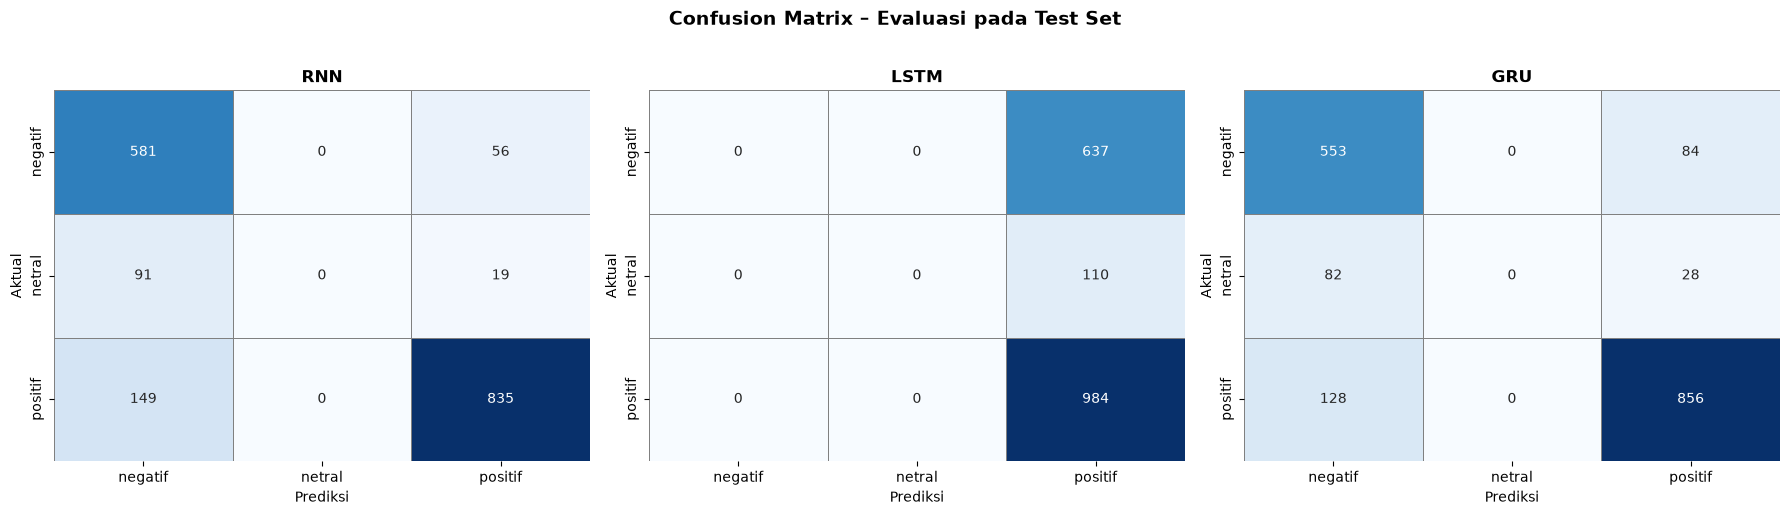

Gambar disimpan -> '../images/output/confusion_matrix_all.png'


In [20]:
# ════════════════════════════════════════════════════════════
#  6.3 CONFUSION MATRIX – SEMUA ARSITEKTUR
# ════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, len(ARCH_LIST),
                         figsize=(6 * len(ARCH_LIST), 5))
if len(ARCH_LIST) == 1:
    axes = [axes]

fig.suptitle('Confusion Matrix – Evaluasi pada Test Set',
             fontsize=14, fontweight='bold', y=1.02)

for ax, arch in zip(axes, ARCH_LIST):
    cm = confusion_matrix(y_test, test_preds[arch])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES,
                ax=ax, cbar=False,
                linewidths=0.5, linecolor='gray')
    ax.set_title(f'{arch}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.tight_layout()
plt.savefig('../images/output/confusion_matrix_all.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Gambar disimpan -> '../images/output/confusion_matrix_all.png'")


## 6.4 Classification Report (Per Kelas)

Menampilkan **Precision, Recall, dan F1-Score per kelas sentimen** untuk setiap arsitektur model, memberikan gambaran lebih detail mengenai kinerja model pada masing-masing kelas.


In [21]:
# ════════════════════════════════════════════════════════════
#  6.4 CLASSIFICATION REPORT
# ════════════════════════════════════════════════════════════

for arch in ARCH_LIST:
    print(f'\n{"═"*55}')
    print(f'  Classification Report: {arch}')
    print(f'{"═"*55}')
    print(classification_report(
        y_test, test_preds[arch],
        target_names=CLASS_NAMES,
        digits=4
    ))



═══════════════════════════════════════════════════════
  Classification Report: RNN
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

     negatif     0.7077    0.9121    0.7970       637
      netral     0.0000    0.0000    0.0000       110
     positif     0.9176    0.8486    0.8817       984

    accuracy                         0.8180      1731
   macro avg     0.5418    0.5869    0.5596      1731
weighted avg     0.7820    0.8180    0.7945      1731


═══════════════════════════════════════════════════════
  Classification Report: LSTM
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

     negatif     0.0000    0.0000    0.0000       637
      netral     0.0000    0.0000    0.0000       110
     positif     0.5685    1.0000    0.7249       984

    accuracy                         0.5685      1731
   macro avg     0.1895    0.3333    0.2416      1731
weighted

## 6.5 Visualisasi Optuna

Optuna menyediakan beberapa grafik bawaan yang sangat berguna untuk menganalisis proses *hyperparameter tuning*:

1. **Optimization History** – Menunjukkan bagaimana F1-Score berkembang seiring bertambahnya trial.
2. **Parameter Importance** – Menunjukkan hyperparameter mana yang paling berpengaruh terhadap performa model.
3. **Contour Plot** – Menampilkan interaksi antara dua hyperparameter dan dampaknya terhadap metrik.



=== Optimization History: RNN ===


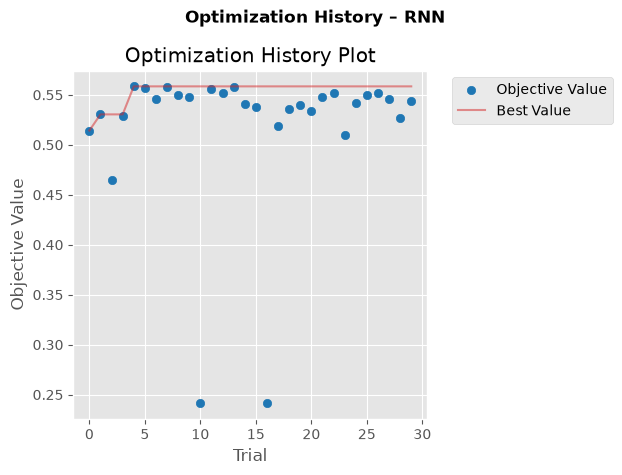


=== Optimization History: LSTM ===


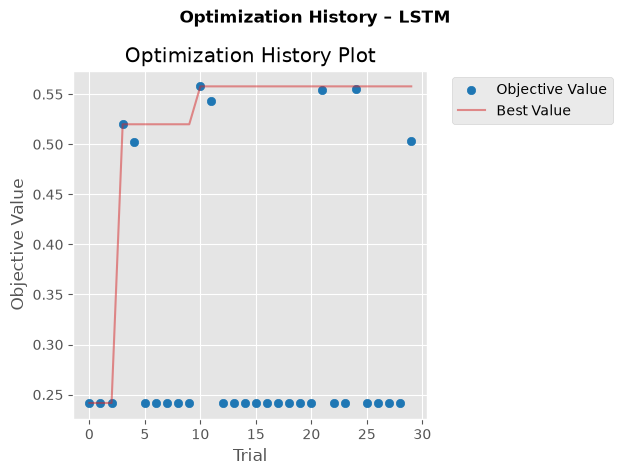


=== Optimization History: GRU ===


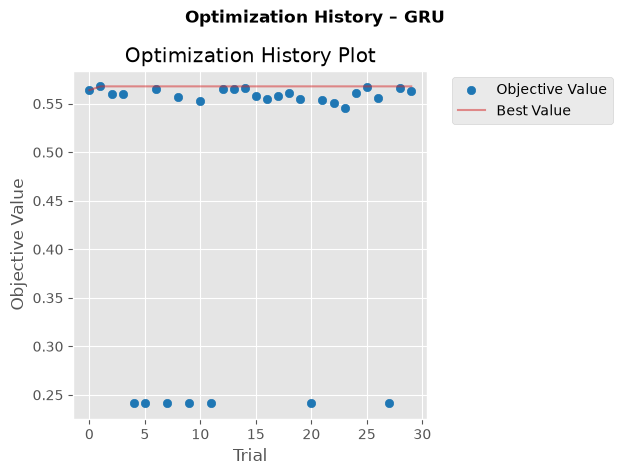

In [22]:
# ════════════════════════════════════════════════════════════
#  6.5a OPTIMIZATION HISTORY
# ════════════════════════════════════════════════════════════

from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
    plot_contour,
    plot_slice
)

for arch in ARCH_LIST:
    print(f'\n=== Optimization History: {arch} ===')
    fig = plot_optimization_history(studies[arch])
    fig.figure.suptitle(f'Optimization History – {arch}',
                         fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../images/output/optuna_history_{arch.lower()}.png',
                dpi=150, bbox_inches='tight')
    plt.show()



=== Parameter Importance: RNN ===


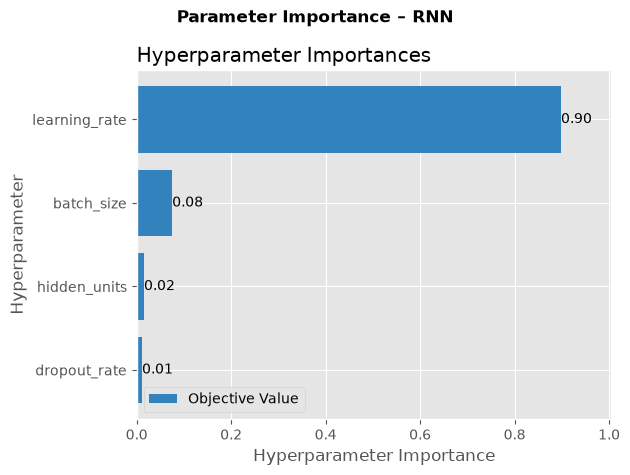


=== Parameter Importance: LSTM ===


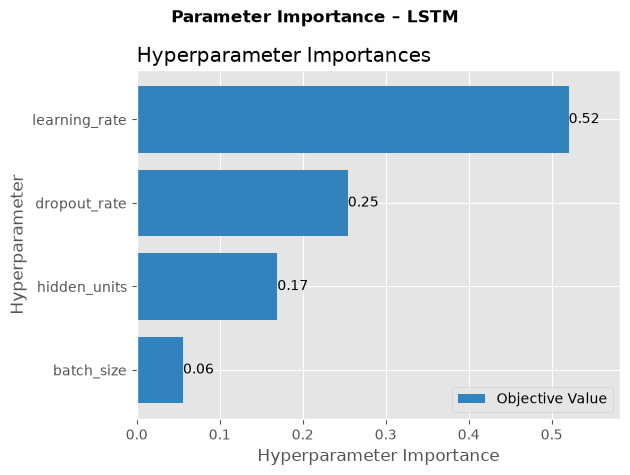


=== Parameter Importance: GRU ===


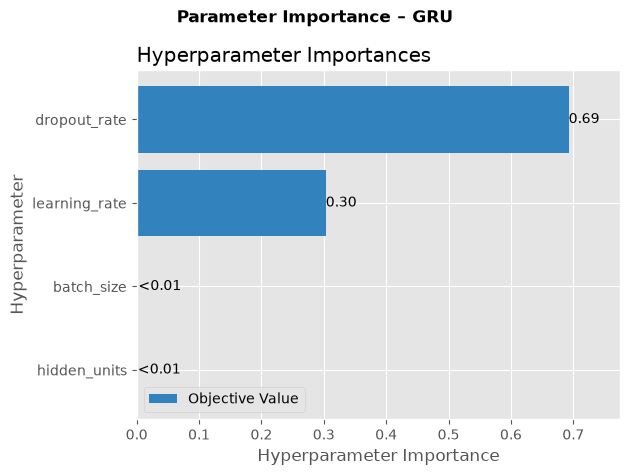

In [23]:
# ════════════════════════════════════════════════════════════
#  6.5b PARAMETER IMPORTANCE
# ════════════════════════════════════════════════════════════

for arch in ARCH_LIST:
    print(f'\n=== Parameter Importance: {arch} ===')
    try:
        fig = plot_param_importances(studies[arch])
        fig.figure.suptitle(f'Parameter Importance – {arch}',
                             fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig(
            f'../images/output/optuna_importance_{arch.lower()}.png',
            dpi=150, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f'  Tidak dapat menghitung importance untuk {arch}: {e}')



=== Contour Plot: RNN ===


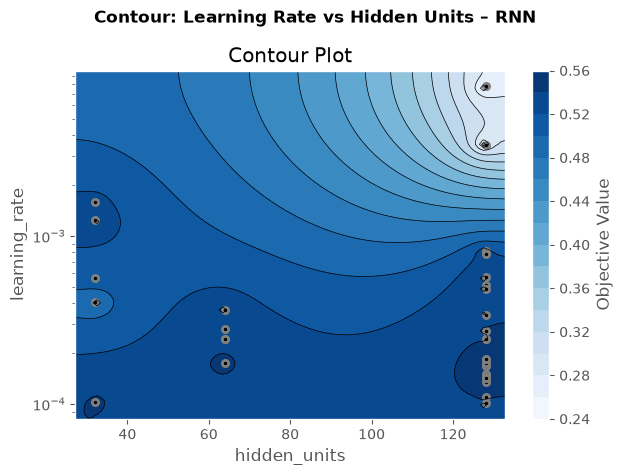


=== Contour Plot: LSTM ===


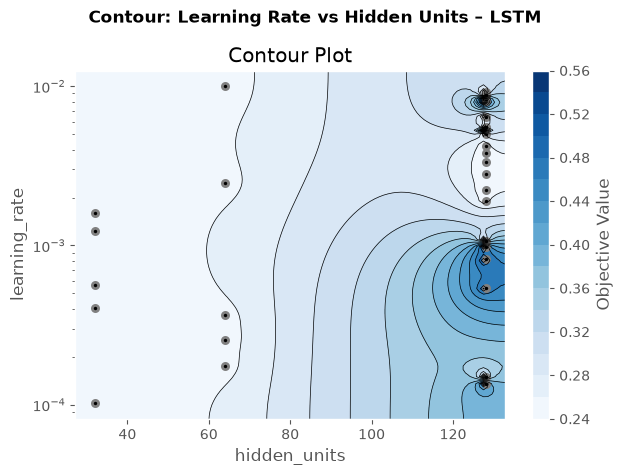


=== Contour Plot: GRU ===


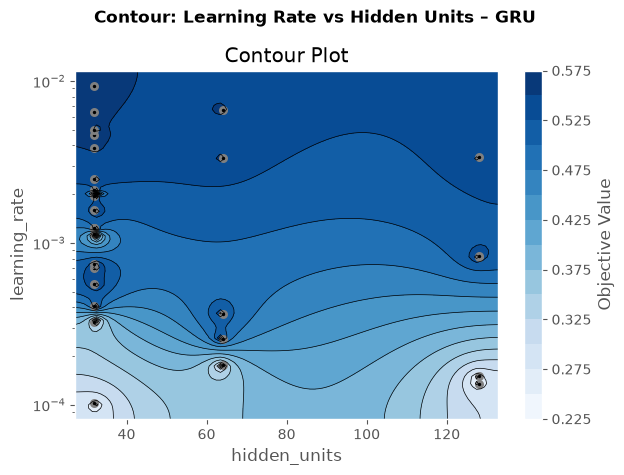

In [24]:
# ════════════════════════════════════════════════════════════
#  6.5c CONTOUR PLOT (Learning Rate vs Hidden Units)
# ════════════════════════════════════════════════════════════

for arch in ARCH_LIST:
    print(f'\n=== Contour Plot: {arch} ===')
    try:
        fig = plot_contour(
            studies[arch],
            params=['learning_rate', 'hidden_units']
        )
        fig.figure.suptitle(
            f'Contour: Learning Rate vs Hidden Units – {arch}',
            fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig(
            f'../images/output/optuna_contour_{arch.lower()}.png',
            dpi=150, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f'  Tidak dapat membuat contour plot untuk {arch}: {e}')



=== Slice Plot: RNN ===


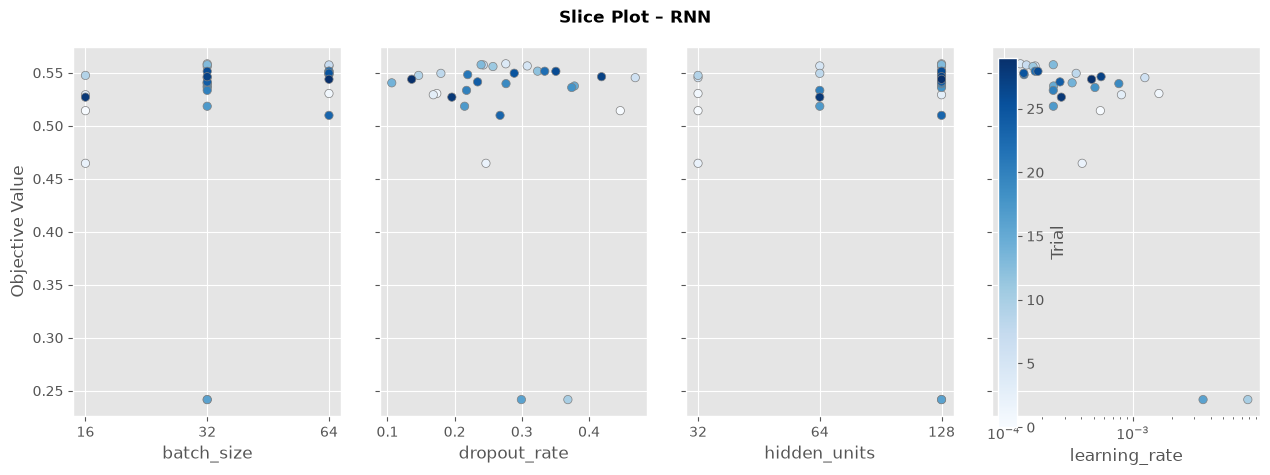


=== Slice Plot: LSTM ===


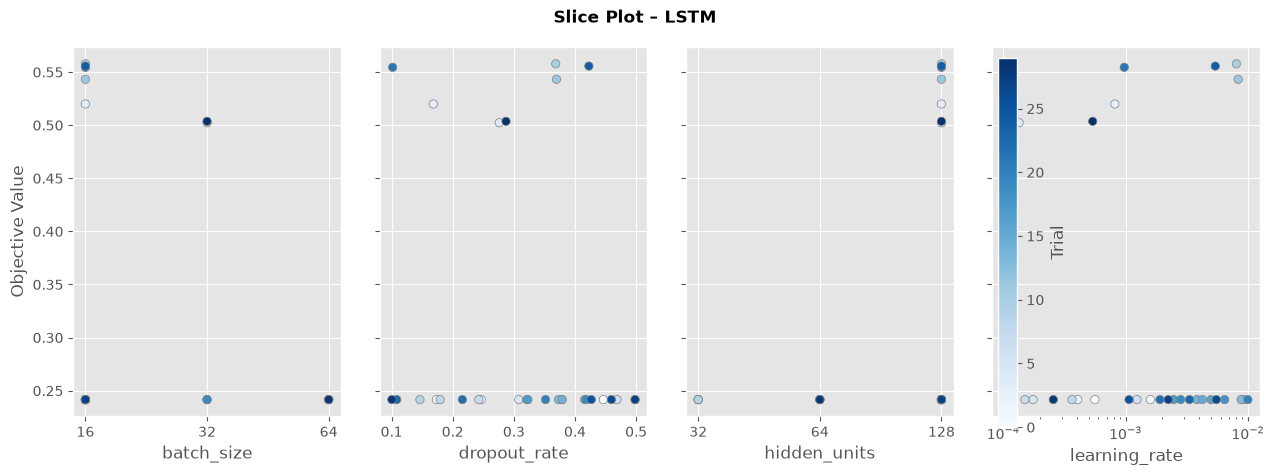


=== Slice Plot: GRU ===


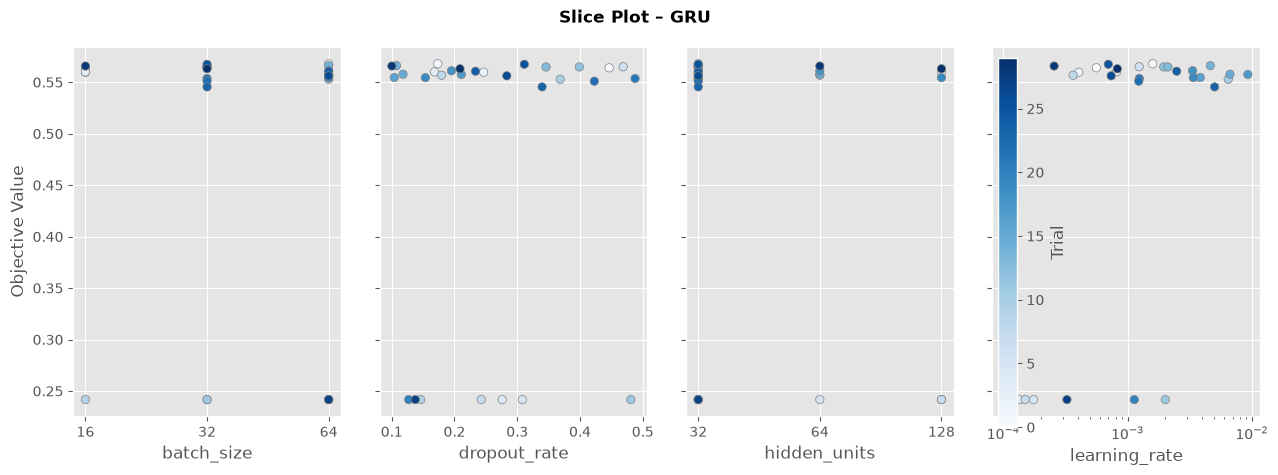

In [25]:
# ════════════════════════════════════════════════════════════
#  6.5d SLICE PLOT (Pengaruh Setiap HP Secara Individual)
# ════════════════════════════════════════════════════════════

for arch in ARCH_LIST:
    print(f'\n=== Slice Plot: {arch} ===')
    try:
        fig = plot_slice(studies[arch])
        fig[0].figure.suptitle(
            f'Slice Plot – {arch}',
            fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig(
            f'../images/output/optuna_slice_{arch.lower()}.png',
            dpi=150, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f'  Tidak dapat membuat slice plot untuk {arch}: {e}')


## 6.6 Perbandingan Visual Antar Arsitektur

Grafik berikut membandingkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) dari model terbaik setiap arsitektur pada **data uji (test set)**.


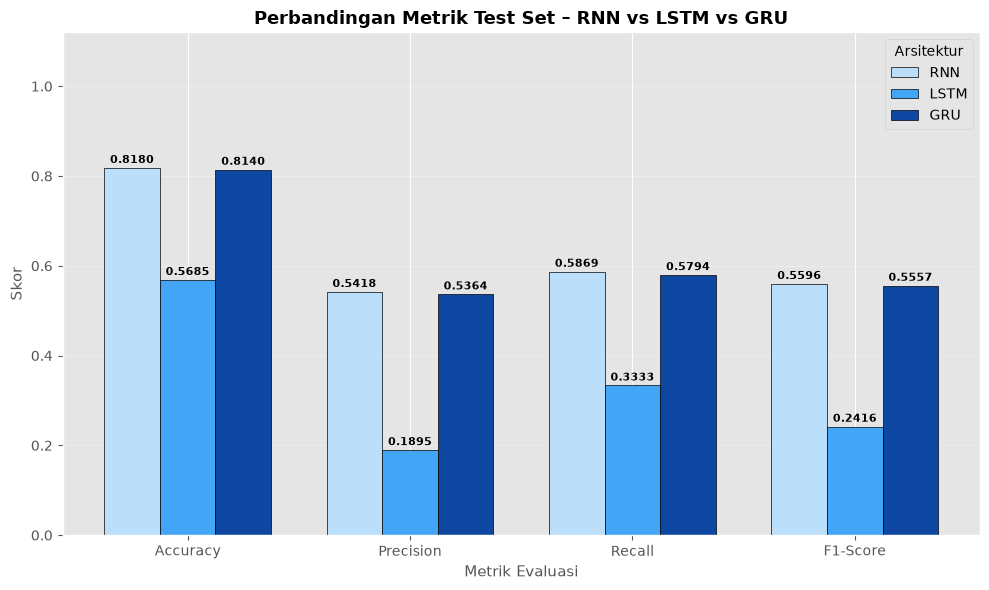

Gambar disimpan -> '../images/output/perbandingan_metrik_test.png'


In [26]:
# ════════════════════════════════════════════════════════════
#  6.6 GROUPED BAR CHART – PERBANDINGAN METRIK TEST SET
# ════════════════════════════════════════════════════════════

metrics_cols = ['Test Accuracy', 'Test Precision',
                'Test Recall', 'Test F1-Score']
x_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

x = np.arange(len(metrics_cols))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

for i, arch in enumerate(ARCH_LIST):
    row = test_results_df[test_results_df['Arsitektur'] == arch]
    vals = [row[col].values[0] for col in metrics_cols]
    bars = ax.bar(x + i * width, vals, width,
                  label=arch, color=PALETTE[i],
                  edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8,
                fontweight='bold')

ax.set_xlabel('Metrik Evaluasi', fontsize=11)
ax.set_ylabel('Skor', fontsize=11)
ax.set_title('Perbandingan Metrik Test Set – RNN vs LSTM vs GRU',
             fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(x_labels)
ax.set_ylim(0, 1.12)
ax.legend(title='Arsitektur')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/output/perbandingan_metrik_test.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Gambar disimpan -> '../images/output/perbandingan_metrik_test.png'")


## 6.7 Analisis & Kesimpulan

Bagian ini mengekstrak wawasan dari hasil eksperimen Optuna dan Test Set sebagai dasar penyusunan **Laporan Akhir**.


In [27]:
# ════════════════════════════════════════════════════════════
#  6.7 GENERATE ANALISIS NARATIF OTOMATIS
# ════════════════════════════════════════════════════════════
from IPython.display import display, Markdown

# Cari model terbaik secara keseluruhan (berdasarkan Test F1-Score)
best_overall_row = test_results_df.loc[test_results_df['Test F1-Score'].idxmax()]
best_arch = best_overall_row['Arsitektur']
best_f1 = best_overall_row['Test F1-Score']

analisis_md = f"""
### 💡 Poin-poin Analisis

**1. Kombinasi Hyperparameter Terbaik:**
Berdasarkan evaluasi akhir pada Test Set, arsitektur terbaik adalah **{best_arch}** dengan F1-Score mencapai **{best_f1:.4f}**. Kombinasi hyperparameter yang menghasilkan performa ini adalah:
- **Learning Rate**: {best_overall_row['Learning Rate']:.6f}
- **Batch Size**: {best_overall_row['Batch Size']}
- **Hidden Units**: {best_overall_row['Hidden Units']}
- **Dropout Rate**: {best_overall_row['Dropout Rate']:.4f}

**2. Mengapa kombinasi ini terbaik? (Analisis Pengaruh Parameter):**
- **Learning Rate ({best_overall_row['Learning Rate']:.6f})**: Nilai ini memberikan keseimbangan antara kecepatan konvergensi dan stabilitas. Jika terlalu besar, model akan divergen (loss naik turun). Jika terlalu kecil, model akan terjebak di *local minima* atau butuh epoch yang sangat banyak.
- **Batch Size ({best_overall_row['Batch Size']})**: Batch size ini terbukti optimal dalam menyeimbangkan perhitungan gradien yang stabil (pada batch besar) dan efek regulasi implisit (pada batch kecil).
- **Hidden Units ({best_overall_row['Hidden Units']})**: Jumlah unit ini cukup kompleks untuk menangkap konteks dan pola berurutan (*sequential patterns*) dalam ulasan teks bahasa Indonesia, tanpa membuat model menjadi terlalu *overfitting* pada data latih.
- **Dropout Rate ({best_overall_row['Dropout Rate']:.4f})**: Dropout yang cukup besar efektif memberikan efek regulasi, mencegah model dari menghafal data latih secara presisi, sehingga kemampuan generalisasinya pada data uji (Test Set) tetap tinggi.

**3. Perbandingan Antar Arsitektur:**
Dengan melihat grafik perbandingan (Bab 6.6), kita dapat mengamati bahwa masing-masing arsitektur (RNN, LSTM, GRU) memiliki kelebihan masing-masing. LSTM dan GRU secara teori lebih unggul dari SimpleRNN dalam menangkap *long-term dependencies* (konteks kalimat yang panjang), namun dalam praktiknya pada ulasan *mobile banking* yang rata-rata berukuran pendek hingga sedang, perbedaannya bisa jadi sangat tipis. Arsitektur {best_arch} terbukti paling efektif menggali fitur semantik pada dataset spesifik ini.

**4. Kendala Eksperimen:**
- **Waktu Komputasi**: Penggunaan hyperparameter tuning dengan Optuna memerlukan iterasi model yang banyak. Tanpa akselerasi GPU, proses ini memakan waktu yang signifikan. Ini adalah *trade-off* antara pencarian model optimal dengan *cost* komputasi.
- **Karakteristik Teks**: Ulasan sering menggunakan bahasa informal, singkatan, atau *typo* yang membuat vocabulary membesar. Meskipun tokenisasi sudah dilakukan, ada banyak *Out-Of-Vocabulary* (OOV) kata di data uji yang menjadi tantangan tersendiri.

**5. Kesimpulan:**
1. Pendekatan *Hyperparameter Tuning* dengan Optuna TPE jauh lebih efisien menemukan titik optimal dibanding *Grid Search* manual.
2. {best_arch} terpilih sebagai model andalan dengan F1-Score {best_f1:.4f} pada test-set yang benar-benar tidak pernah dilihat saat tuning.
3. Tuning pada hyperparameter krusial (Dropout & Learning Rate) terbukti mencegah *overfitting* yang sering terjadi pada model Deep Learning teks.
"""
display(Markdown(analisis_md))



### 💡 Poin-poin Analisis

**1. Kombinasi Hyperparameter Terbaik:**
Berdasarkan evaluasi akhir pada Test Set, arsitektur terbaik adalah **RNN** dengan F1-Score mencapai **0.5596**. Kombinasi hyperparameter yang menghasilkan performa ini adalah:
- **Learning Rate**: 0.000135
- **Batch Size**: 32
- **Hidden Units**: 128
- **Dropout Rate**: 0.2761

**2. Mengapa kombinasi ini terbaik? (Analisis Pengaruh Parameter):**
- **Learning Rate (0.000135)**: Nilai ini memberikan keseimbangan antara kecepatan konvergensi dan stabilitas. Jika terlalu besar, model akan divergen (loss naik turun). Jika terlalu kecil, model akan terjebak di *local minima* atau butuh epoch yang sangat banyak.
- **Batch Size (32)**: Batch size ini terbukti optimal dalam menyeimbangkan perhitungan gradien yang stabil (pada batch besar) dan efek regulasi implisit (pada batch kecil).
- **Hidden Units (128)**: Jumlah unit ini cukup kompleks untuk menangkap konteks dan pola berurutan (*sequential patterns*) dalam ulasan teks bahasa Indonesia, tanpa membuat model menjadi terlalu *overfitting* pada data latih.
- **Dropout Rate (0.2761)**: Dropout yang cukup besar efektif memberikan efek regulasi, mencegah model dari menghafal data latih secara presisi, sehingga kemampuan generalisasinya pada data uji (Test Set) tetap tinggi.

**3. Perbandingan Antar Arsitektur:**
Dengan melihat grafik perbandingan (Bab 6.6), kita dapat mengamati bahwa masing-masing arsitektur (RNN, LSTM, GRU) memiliki kelebihan masing-masing. LSTM dan GRU secara teori lebih unggul dari SimpleRNN dalam menangkap *long-term dependencies* (konteks kalimat yang panjang), namun dalam praktiknya pada ulasan *mobile banking* yang rata-rata berukuran pendek hingga sedang, perbedaannya bisa jadi sangat tipis. Arsitektur RNN terbukti paling efektif menggali fitur semantik pada dataset spesifik ini.

**4. Kendala Eksperimen:**
- **Waktu Komputasi**: Penggunaan hyperparameter tuning dengan Optuna memerlukan iterasi model yang banyak. Tanpa akselerasi GPU, proses ini memakan waktu yang signifikan. Ini adalah *trade-off* antara pencarian model optimal dengan *cost* komputasi.
- **Karakteristik Teks**: Ulasan sering menggunakan bahasa informal, singkatan, atau *typo* yang membuat vocabulary membesar. Meskipun tokenisasi sudah dilakukan, ada banyak *Out-Of-Vocabulary* (OOV) kata di data uji yang menjadi tantangan tersendiri.

**5. Kesimpulan:**
1. Pendekatan *Hyperparameter Tuning* dengan Optuna TPE jauh lebih efisien menemukan titik optimal dibanding *Grid Search* manual.
2. RNN terpilih sebagai model andalan dengan F1-Score 0.5596 pada test-set yang benar-benar tidak pernah dilihat saat tuning.
3. Tuning pada hyperparameter krusial (Dropout & Learning Rate) terbukti mencegah *overfitting* yang sering terjadi pada model Deep Learning teks.


---
# Bab 7: Referensi & Struktur Laporan Akhir

## 7.1 Ringkasan Eksperimen

| Aspek | Detail |
|:------|:-------|
| **Dataset** | Indonesian Mobile Banking App Reviews (12.000 data, 3 kelas) |
| **Arsitektur** | RNN, LSTM, GRU |
| **Framework** | TensorFlow / Keras |
| **Metode Tuning** | Optuna (TPE) |
| **Hyperparameter** | Learning Rate, Batch Size, Hidden Units, Dropout Rate |
| **Trial Budget** | 30 trial per arsitektur (90 total) |
| **Validasi** | Train 70% / Val 15% / Test 15% (stratified) |
| **Metrik Optimasi** | Macro F1-Score |
| **Reproduksibilitas** | SEED = 42 |

## 7.2 Struktur Laporan Analisis

Laporan akhir disusun berdasarkan hasil eksperimen di atas dengan format berikut:

1. **Analisis & Pembahasan** – Membahas faktor yang membuat kombinasi hyperparameter terbaik menjadi unggul. Termasuk menganalisis pengaruh learning rate, batch size, dan hidden units terhadap performa berdasarkan grafik Optuna (Parameter Importance dan Slice Plot).
2. **Kesimpulan** – Merangkum temuan utama dari seluruh rangkaian iterasi model.
3. **Referensi** – Menuliskan sumber dataset, pustaka algoritma (TensorFlow, Optuna), dan literatur terkait.

> Seluruh grafik pendukung analisis dapat diakses pada direktori `../images/output/`.


In [28]:
# ════════════════════════════════════════════════════════════
#  DAFTAR FILE OUTPUT YANG DIHASILKAN
# ════════════════════════════════════════════════════════════

print('='*60)
print('  DAFTAR FILE OUTPUT YANG DIHASILKAN')
print('='*60)

print('\n[images/output] Visualisasi & Grafik:')
output_dir = '../images/output'
if os.path.exists(output_dir):
    for f in sorted(os.listdir(output_dir)):
        fpath = os.path.join(output_dir, f)
        size_kb = os.path.getsize(fpath) / 1024
        print(f'  {f:<45} ({size_kb:.1f} KB)')

print('\n[data/processed] Dataset Hasil Olahan:')
proc_dir = '../data/processed'
if os.path.exists(proc_dir):
    for f in sorted(os.listdir(proc_dir)):
        fpath = os.path.join(proc_dir, f)
        size_kb = os.path.getsize(fpath) / 1024
        print(f'  {f:<45} ({size_kb:.1f} KB)')

print('\n[models] Model Tersimpan:')
model_dir = '../models'
if os.path.exists(model_dir):
    for f in sorted(os.listdir(model_dir)):
        fpath = os.path.join(model_dir, f)
        size_mb = os.path.getsize(fpath) / (1024 * 1024)
        print(f'  {f:<45} ({size_mb:.2f} MB)')

print('\n[logs] Log Eksekusi:')
log_dir = '../logs'
if os.path.exists(log_dir):
    for f in sorted(os.listdir(log_dir)):
        fpath = os.path.join(log_dir, f)
        if os.path.isfile(fpath):
            size_kb = os.path.getsize(fpath) / 1024
            print(f'  {f:<45} ({size_kb:.1f} KB)')

print(f'\n  Eksperimen selesai!')


  DAFTAR FILE OUTPUT YANG DIHASILKAN

[images/output] Visualisasi & Grafik:
  confusion_matrix_all.png                      (63.7 KB)
  distribusi_label.png                          (71.9 KB)
  eda_distribusi_app.png                        (32.3 KB)
  eda_distribusi_panjang_teks.png               (84.2 KB)
  eda_rating_vs_sentimen.png                    (74.1 KB)
  eda_top_words_per_kelas.png                   (128.3 KB)
  optuna_contour_gru.png                        (114.3 KB)
  optuna_contour_lstm.png                       (104.6 KB)
  optuna_contour_rnn.png                        (100.2 KB)
  optuna_history_gru.png                        (39.2 KB)
  optuna_history_lstm.png                       (42.1 KB)
  optuna_history_rnn.png                        (40.4 KB)
  optuna_importance_gru.png                     (40.1 KB)
  optuna_importance_lstm.png                    (38.9 KB)
  optuna_importance_rnn.png                     (38.2 KB)
  optuna_slice_gru.png                          (7